# Kerr BH in Kerr-Schild Coordinate

In [1]:
Needs["xAct`xCoba`", FileNameJoin[{Environment["GENERATO"], "src/Generato.wl"}]];

------------------------------------------------------------
Package xAct`xPerm`  version 1.2.4, {2025, 12, 29}
CopyRight (C) 2003-2026, Jose M. Martin-Garcia, under the General Public\
 
>   License.
Connecting to external mac executable...
Connection established.
------------------------------------------------------------
Package xAct`xTensor` version 1.3.0, {2025, 12, 29}
CopyRight (C) 2002-2026, Jose M. Martin-Garcia, under the General Public\
 
>   License.
------------------------------------------------------------
These packages come with ABSOLUTELY NO WARRANTY; for details type\
 
>   Disclaimer[]. This is free software, and you are welcome to redistribute\
 
>   it under certain conditions. See the General Public License for details.
------------------------------------------------------------
------------------------------------------------------------
Package xAct`xCoba`  version 0.8.6, {2021, 2, 28}
CopyRight (C) 2005-2026, David Yllanes and Jose M. Martin-Garcia, under t

In [2]:
DefManifold[M3, 3, IndexRange[a, z]];

In [3]:
DefChart[cart, M3, {1, 2, 3}, {X[], Y[], Z[]}, ChartColor -> Blue];

In [4]:
(* set mode to check equations *)
SetCheckInputEquations[True];

In [6]:
Get[FileNameJoin[{Environment["GENERATO"], "module/ADM/ADM_var.wl"}]];

In [7]:
Get["wl/KerrSchild_var.wl"];
Get["wl/KerrSchild_rhs.wl"];

## Auxiliary Variables

$$
\begin{align}
k_a
&=
\left(
    1, \frac{rx+ay}{r^2+a^2}, \frac{ry-ax}{r^2+a^2}, \frac{z}{r}
\right)
\\
f
&=\frac{r^2}{r^4+a^2z^2}2Mr
\\
g_{ab}
&=\eta_{ab}+fk_ak_b
\\
\beta_i
&=g_{0i}=fk_0k_i
\\
\alpha
&=
\left(
    1+\frac{2Mr^3}{r^4+a^2z^2}
\right)^{-1/2}
\end{align}
$$

-Image-
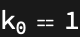

In [9]:
Rasterize[KSk0[] == (KSk0[] // ToValues)]

-Image-
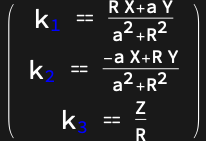

In [10]:
Rasterize[Table[KSk[{ii,-cart}] == (KSk[{ii,-cart}] // ToValues), {ii,1,3}] // MatrixForm]

-Image-
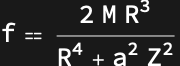

In [11]:
Rasterize[KSf[] == (KSf[] // ToValues)]

-Image-
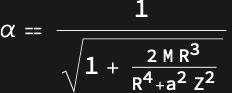

In [12]:
Rasterize[KSalpha[] == (KSalpha[] // ToValues)]

-Image-
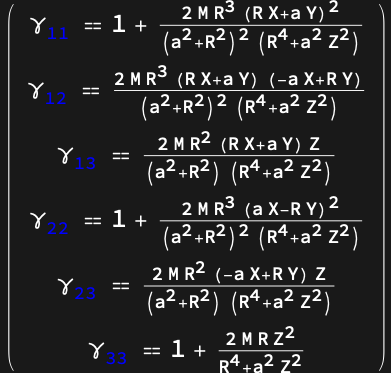

In [13]:
Rasterize[Flatten@Table[KSgam[{ii,-cart},{jj,-cart}] == (KSgam[{ii,-cart},{jj,-cart}] // ToValues), {ii,1,3}, {jj,ii,3}] // MatrixForm]

-Image-
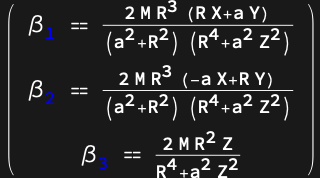

In [14]:
Rasterize[Table[KSbeta[{ii,-cart}] == (KSbeta[{ii,-cart}] // ToValues), {ii,1,3}] // MatrixForm]

with
$$
\frac{x^2+y^2}{r^2+a^2}+\frac{z^2}{r^2}=1
$$

In [15]:
(X[]^2 + Y[]^2) / (rad$expl^2 + angv^2) + Z[]^2 / rad$expl^2 // Expand // Simplify

1

where $r$ is calcualted from

2      2      2      2
{{r -> -(Sqrt[-angv  + X[]  + Y[]  + Z[]  - 
 
                      2    2        2      2      2      2 2
>          Sqrt[4 angv  Z[]  + (angv  - X[]  - Y[]  - Z[] ) ]] / Sqrt[2])}, 
 
                    2      2      2      2
>   {r -> Sqrt[-angv  + X[]  + Y[]  + Z[]  - 
 
                    2    2        2      2      2      2 2
>        Sqrt[4 angv  Z[]  + (angv  - X[]  - Y[]  - Z[] ) ]] / Sqrt[2]}, 
 
                      2      2      2      2
>   {r -> -(Sqrt[-angv  + X[]  + Y[]  + Z[]  + 
 
                      2    2        2      2      2      2 2
>          Sqrt[4 angv  Z[]  + (angv  - X[]  - Y[]  - Z[] ) ]] / Sqrt[2])}, 
 
                    2      2      2      2
>   {r -> Sqrt[-angv  + X[]  + Y[]  + Z[]  + 
 
                    2    2        2      2      2      2 2
>        Sqrt[4 angv  Z[]  + (angv  - X[]  - Y[]  - Z[] ) ]] / Sqrt[2]}}
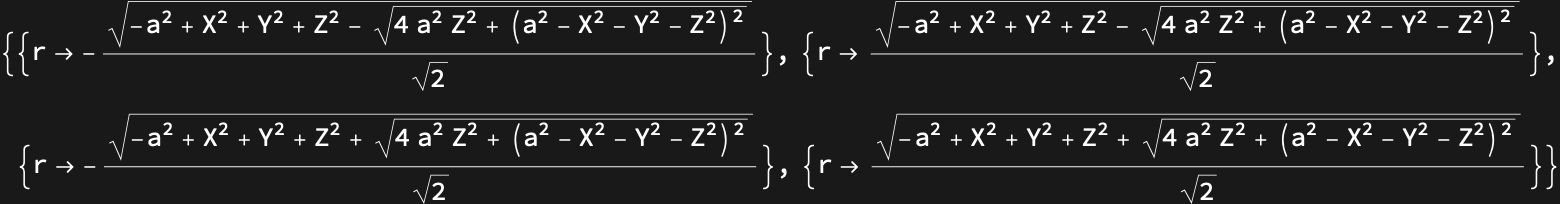

In [16]:
Solve[(X[]^2 + Y[]^2)/(r^2 + angv^2) + Z[]^2/r^2 == 1, r]

## Temporary Variables

-Image-
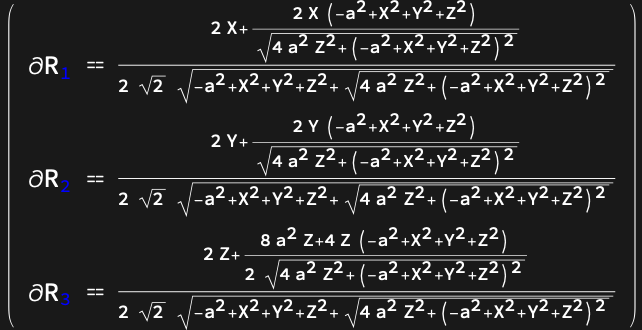

In [17]:
Rasterize[Table[drad[{ii,-cart}] == (drad$RHS[{ii,-cart}] // ToValues), {ii,1,3}] // MatrixForm]

-Image-
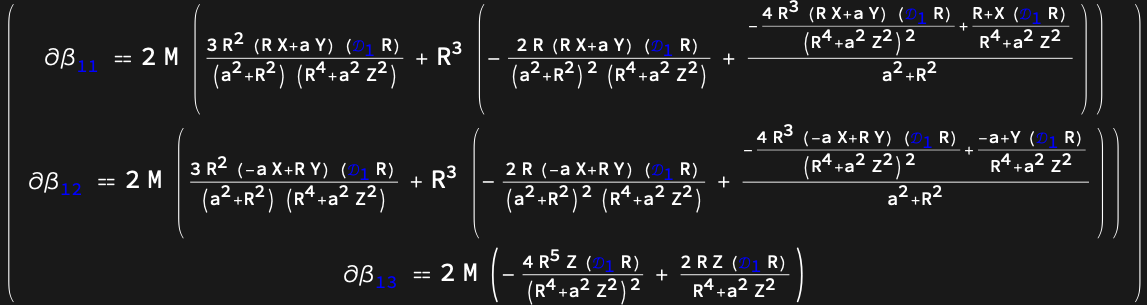

In [18]:
Rasterize[Flatten@Table[dbetaDD[{1,-cart}, {ii,-cart}] == (dbetaDD$RHS[{1,-cart}, {ii,-cart}] // ToValues), {ii,1,3}] // MatrixForm]

-Image-
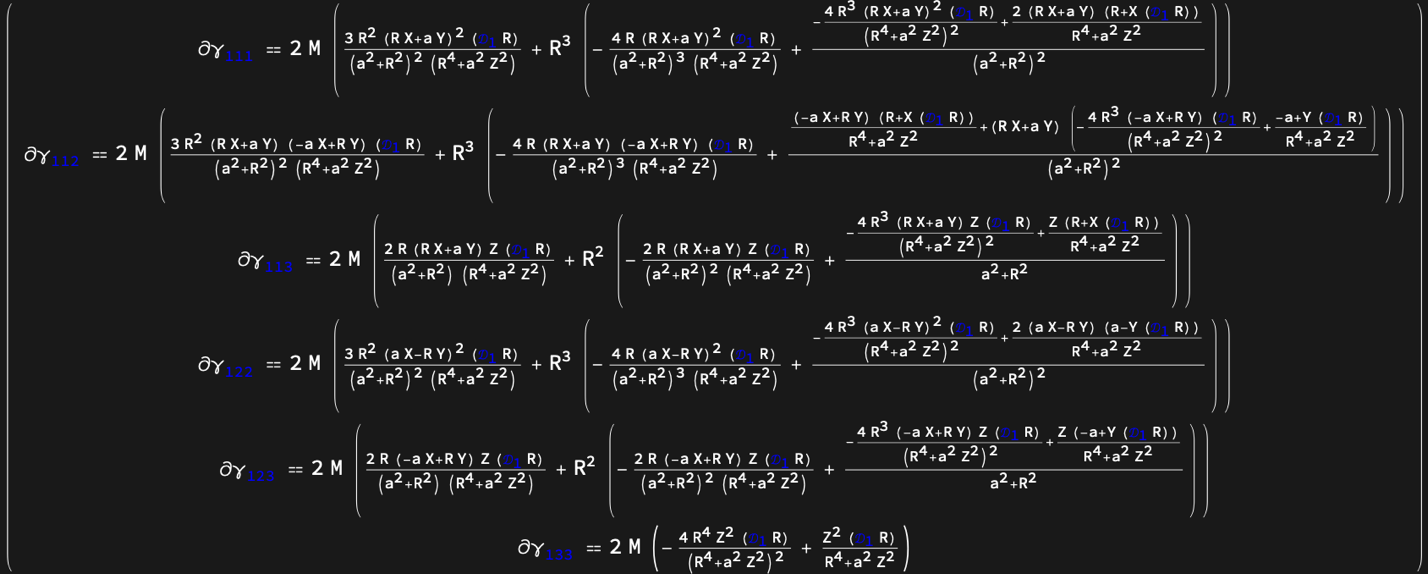

In [19]:
Rasterize[Flatten@Table[dgamDDD[{1,-cart}, {ii,-cart}, {jj,-cart}] == (dgamDDD$RHS[{1,-cart}, {ii,-cart}, {jj,-cart}] // ToValues), {ii,1,3}, {jj,ii,3}] // MatrixForm]

In [20]:
rhsof[var_] := Module[{}, var /. {var[[0]] :> RHSOf[ToString[var[[0]]]]}];
eqssof[varlist_] := Module[{var}, 
   Table[var = varlist[[ivar]][[1]]; var == rhsof[var]//ScreenDollarIndices, {ivar, 1, Length[varlist]}]];

-Image-
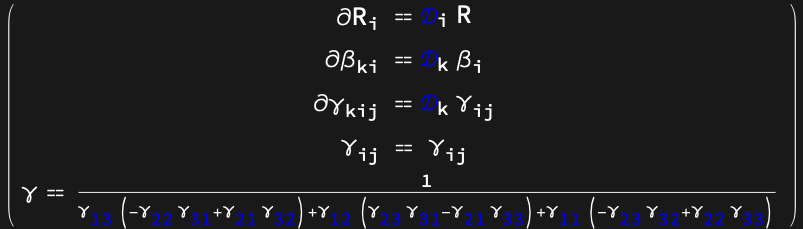

In [22]:
eqssof[KerrSchildTempVarlist[[2;;6]]] // MatrixForm // Rasterize

-Image-
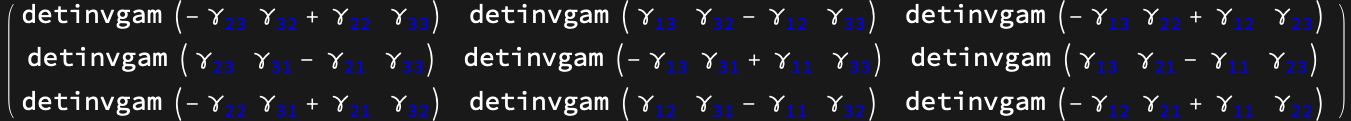

In [23]:
Table[invgam$RHS[{ii, cart}, {jj, cart}] // ToValues, {ii, 1, 3}, {jj, 1, 3}] // MatrixForm // Rasterize

-Image-
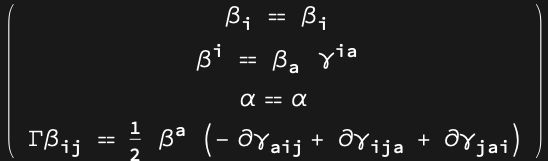

In [24]:
eqssof[KerrSchildTempVarlist[[8;;-1]]] // MatrixForm // Rasterize

## ADM Variables

-Image-
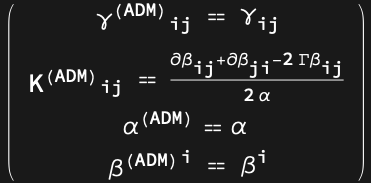

In [25]:
Rasterize[eqssof[ADMVarlist] // MatrixForm]